# SDSS Galaxies vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 

This is one of the most famous example of machine-learning classification in astronomy. For some recent work see e.g. 
- *Identifying galaxies, quasars, and stars with machine learning: A new catalogue of classifications for 111 million SDSS sources without spectra* Clarke et al (2019) [arXiv:1909.10963](https://arxiv.org/abs/1909.10963)
- *Quasar and galaxy classification in Gaia Data Release 2* Bailer-Jones et al (2019) [arXiv:1910.05255](https://arxiv.org/abs/1910.05255)



The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new in computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_predict

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, ConfusionMatrixDisplay

### Dataset

In [240]:
data = pd.read_csv('galaxyquasar.csv')
print(data)

              u         g         r         i         z   class        z1  \
0      18.97213  18.53676  18.58280  18.34936  18.29215     QSO  0.522819   
1      19.24592  17.47646  16.47817  16.04472  15.68851  GALAXY  0.122846   
2      19.43536  17.70268  16.91565  16.58327  16.39128  GALAXY  0.000000   
3      19.31626  18.18312  17.39591  16.94549  16.65395  GALAXY  0.147435   
4      19.28828  19.11188  18.88937  18.80013  18.49183     QSO  2.011455   
...         ...       ...       ...       ...       ...     ...       ...   
49995  19.37295  18.12382  17.39886  16.98503  16.70585  GALAXY  0.113016   
49996  18.52021  16.88262  16.03280  15.56884  15.22454  GALAXY  0.085063   
49997  18.62718  17.30876  16.87371  16.62399  16.42296  GALAXY  0.054429   
49998  19.55140  18.27711  17.62101  17.21947  17.03347  GALAXY  0.112571   
49999  18.80772  17.75751  17.40500  17.21650  17.12295  GALAXY  0.043652   

           zerr  
0      0.000155  
1      0.000028  
2      0.000000  
3  

In [241]:
# Color arrays
u_g = np.array(data['u'] - data['g'])
g_r = data['g'] - data['r']
r_i = data['r'] - data['i']
i_z = data['i'] - data['z']

X = np.column_stack((u_g, g_r, r_i, i_z))

# Galaxy or quasar
le = LabelEncoder()
labels = le.fit_transform(data['class']) # galaxy = 0 and quasar = 1

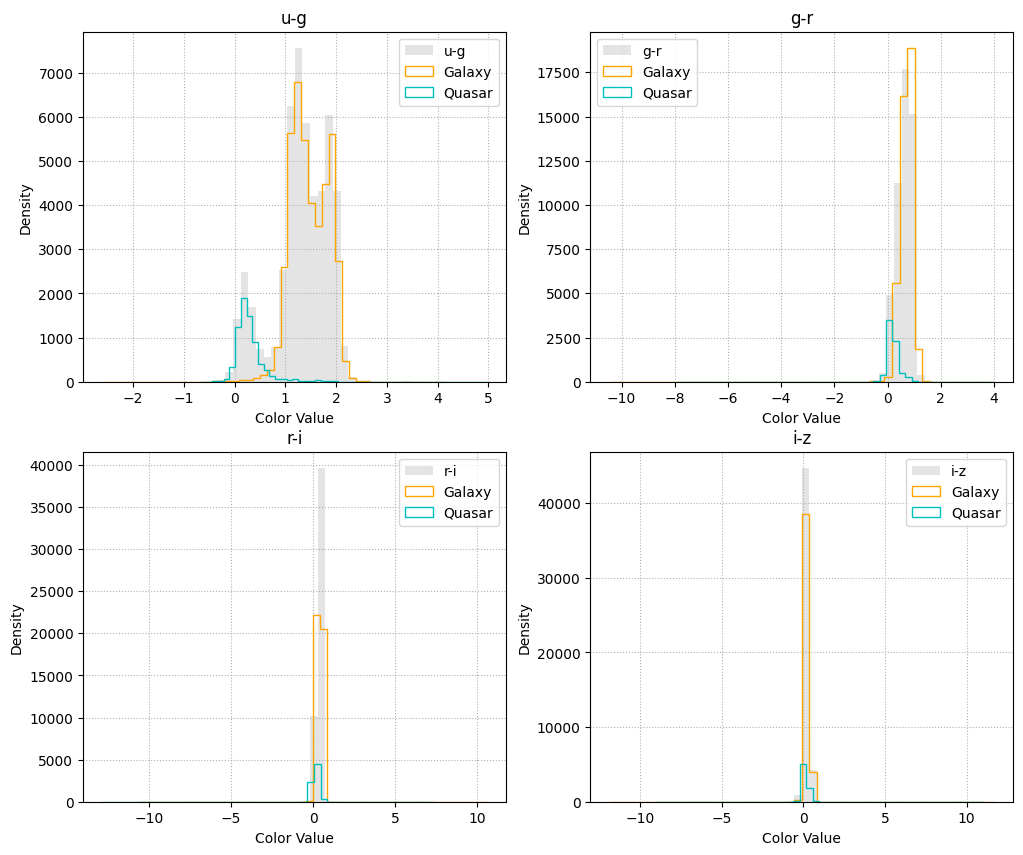

In [242]:
colors = {'u-g': u_g, 'g-r': g_r, 'r-i': r_i, 'i-z': i_z}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, color_array) in enumerate(colors.items()):
    ax = axes[idx]

    # Mask for each class
    galaxy_mask = labels == 0
    quasar_mask = labels == 1

    ax.hist(color_array, bins= 50, color='lightgray', label = name, alpha = 0.6 )
    ax.hist(color_array[galaxy_mask],bins= 50, color='orange', histtype = 'step',label='Galaxy')
    ax.hist(color_array[quasar_mask], bins= 50, color='c', histtype = 'step', label='Quasar')

    ax.set_title(f'{name}')
    ax.set_xlabel('Color Value')
    ax.set_ylabel('Density')
    ax.grid(linestyle = ':')
    ax.legend()

plt.show()

The only one showing off most of the bimodality seems to be the $u-g$ projection so I am first going to investigate it before extending the analysis to the whole dataset.

In [243]:
ug_train, ug_test, y_train, y_test = train_test_split(u_g, labels, test_size=0.3, random_state=1)

X_train, X_test, y_train_AD, y_test_AD =  train_test_split(X, labels, test_size=0.33, random_state=1)

## GMMBayes Classifier

max score is for k=4


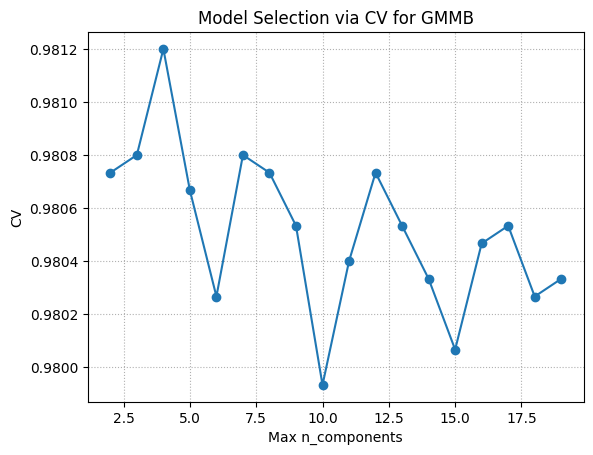

In [244]:
from astroML.classification import GMMBayes
from sklearn.model_selection import KFold

scores = []
kvals = np.arange(2,20)

for k in kvals:
    clf = GMMBayes(k, covariance_type='full', random_state=42)
    CVpredk = cross_val_predict(clf, ug_test[:, None], y_test)
    scores.append(accuracy_score(y_test, CVpredk))

max_k = kvals[np.argmax(scores)]
print(f'max score is for k={max_k}')

plt.plot(kvals, scores, marker='o')
plt.xlabel('Max n_components')
plt.ylabel('CV')
plt.title('Model Selection via CV for GMMB')
plt.grid(linestyle = ':')
plt.show()

ROC AUC: 0.9857142054837682


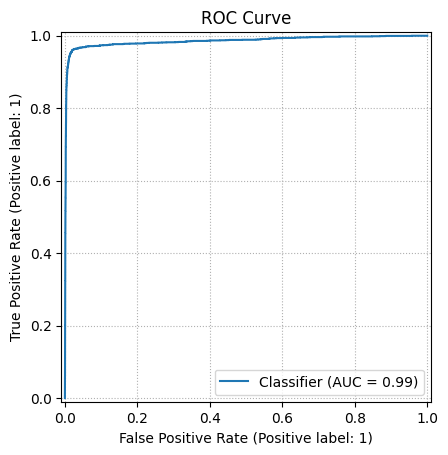

GMMB accuracy: 0.9810666666666666
Completeness: 0.9238
Contamination: 0.0562


In [245]:
GMMB = GMMBayes(n_components=max_k, covariance_type='full')
GMMB.fit(ug_train[:, None], y_train)

y_pred_GMMB_ug = GMMB.predict(ug_test[:, None])
y_proba = GMMB.predict_proba(ug_test[:, None])[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.grid(linestyle = ':')
plt.show()

cm = confusion_matrix(y_test, y_pred_GMMB_ug)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_GMMB_ug).ravel()
completeness_tree = tp / (tp + fn)
contamination_tree = fp / (tp + fp)

print("GMMB accuracy:", accuracy_score(y_test, y_pred_GMMB_ug))
print(f"Completeness: {completeness_tree:.4f}")
print(f"Contamination: {contamination_tree:.4f}")

max score is for k=18


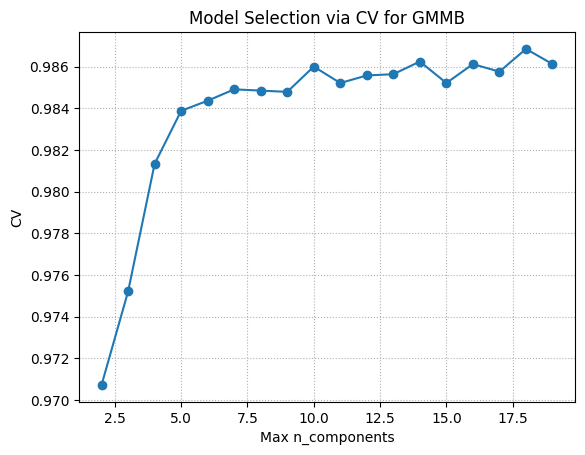

In [246]:
# All Data

scores = []
kvals = np.arange(2,20)

for k in kvals:
    clf = GMMBayes(k, covariance_type='full', random_state=42)
    CVpredk = cross_val_predict(clf, X_test, y_test_AD)
    scores.append(accuracy_score(y_test_AD, CVpredk)) 

max_k = kvals[np.argmax(scores)]
print(f'max score is for k={max_k}')

plt.plot(kvals, scores, marker='o')
plt.xlabel('Max n_components')
plt.ylabel('CV')
plt.title('Model Selection via CV for GMMB')
plt.grid(linestyle = ':')
plt.show()

ROC AUC: 0.9947222457137984


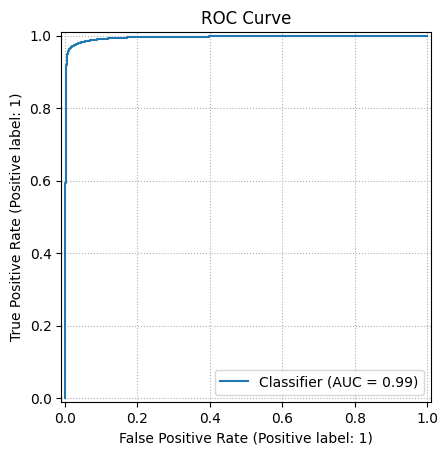

GMMB accuracy: 0.9864848484848485
Completeness: 0.9488
Contamination: 0.0428


In [247]:
GMMB = GMMBayes(n_components=max_k, covariance_type='full')
GMMB.fit(X_train, y_train_AD)

y_pred_GMMB_AD = GMMB.predict(X_test)
y_proba2 = GMMB.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test_AD, y_proba2))

RocCurveDisplay.from_predictions(y_test_AD, y_proba2)
plt.title("ROC Curve")
plt.grid(linestyle = ':')
plt.show()

cm = confusion_matrix(y_test_AD, y_pred_GMMB_AD)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test_AD, y_pred_GMMB_AD).ravel()
completeness = tp / (tp + fn)
contamination = fp / (tp + fp)

print("GMMB accuracy:", accuracy_score(y_test_AD, y_pred_GMMB_AD))
print(f"Completeness: {completeness:.4f}")
print(f"Contamination: {contamination:.4f}")

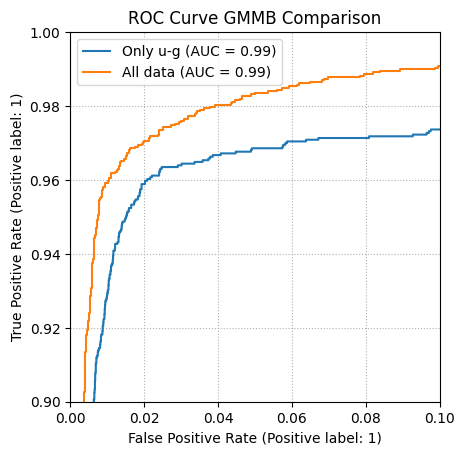

In [248]:
fig, ax = plt.subplots()

RocCurveDisplay.from_predictions(y_test, y_proba, name="Only u-g", ax=ax)
RocCurveDisplay.from_predictions(y_test_AD, y_proba2, name="All data", ax=ax)

ax.set_title("ROC Curve GMMB Comparison")
plt.grid(linestyle = ':')
plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.show()

## K-Neighbours Classifier

In [249]:
scores = []
kvals = np.arange(2,20)

for k in kvals:
    KNeighborsClassifier(n_neighbors=k)
    CVpredk = cross_val_predict(clf, ug_test[:, None], y_test)
    scores.append(accuracy_score(y_test, CVpredk))

max_k = kvals[np.argmax(scores)]
print(f'max score is for k={max_k}')


max score is for k=14


In [250]:
KN = KNeighborsClassifier(n_neighbors=max_k)
KN.fit(ug_train[:, None], y_train)

y_pred_KN_ug = KN.predict(ug_test[:, None])
y_proba = KN.predict_proba(ug_test[:, None])[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred_KN_ug)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_KN_ug).ravel()
completeness_tree = tp / (tp + fn)
contamination_tree = fp / (tp + fp)

print("KN accuracy:", accuracy_score(y_test, y_pred_KN_ug))
print(f"Completeness: {completeness_tree:.4f}")
print(f"Contamination: {contamination_tree:.4f}")

ROC AUC: 0.9796437922398246
KN accuracy: 0.981
Completeness: 0.9335
Contamination: 0.0652


In [251]:
# All Data

scores = []
kvals = np.arange(2,20)

for k in kvals:
    KNeighborsClassifier(n_neighbors=k)
    CVpredk = cross_val_predict(clf, X_test, y_test_AD)
    scores.append(accuracy_score(y_test_AD, CVpredk)) 

max_k = kvals[np.argmax(scores)]
print(f'max score is for k={max_k}')

max score is for k=4


In [252]:
KN = KNeighborsClassifier(n_neighbors=max_k)
KN.fit(X_train, y_train_AD)

y_pred_KN_AD = KN.predict(X_test)
y_proba2 = KN.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test_AD, y_proba2))

cm = confusion_matrix(y_test_AD, y_pred_KN_AD)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test_AD, y_pred_KN_AD).ravel()
completeness = tp / (tp + fn)
contamination = fp / (tp + fp)

print("KN accuracy:", accuracy_score(y_test_AD, y_pred_KN_AD))
print(f"Completeness: {completeness:.4f}")
print(f"Contamination: {contamination:.4f}")

ROC AUC: 0.9855948316867226
KN accuracy: 0.9856969696969697
Completeness: 0.9387
Contamination: 0.0387


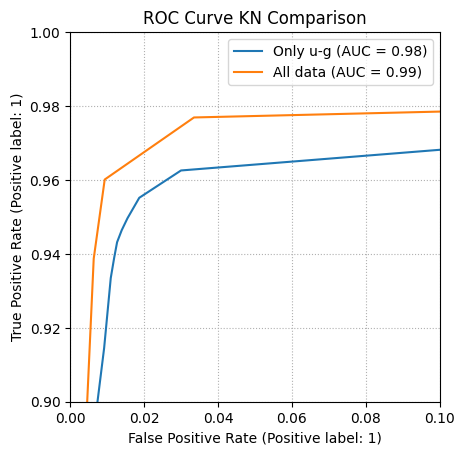

In [253]:
fig, ax = plt.subplots()

RocCurveDisplay.from_predictions(y_test, y_proba, name="Only u-g", ax=ax)
RocCurveDisplay.from_predictions(y_test_AD, y_proba2, name="All data", ax=ax)

ax.set_title("ROC Curve KN Comparison")
plt.grid(linestyle = ':')
plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.show()

## Quadratic Discriminant Analysis

In [254]:
QDA = QuadraticDiscriminantAnalysis()
QDA.fit(ug_train[:, None], y_train)

y_pred_QDA_ug = QDA.predict(ug_test[:, None])
y_proba = QDA.predict_proba(ug_test[:, None])[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred_QDA_ug)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_QDA_ug).ravel()
completeness_tree = tp / (tp + fn)
contamination_tree = fp / (tp + fp)

print("QDA accuracy:", accuracy_score(y_test, y_pred_QDA_ug))
print(f"Completeness: {completeness_tree:.4f}")
print(f"Contamination: {contamination_tree:.4f}")

ROC AUC: 0.9830464687751467
QDA accuracy: 0.9811333333333333
Completeness: 0.9362
Contamination: 0.0668


In [255]:
# All Data

QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train, y_train_AD)

y_pred_QDA_AD = QDA.predict(X_test)
y_proba2 = QDA.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test_AD, y_proba2))

cm = confusion_matrix(y_test_AD, y_pred_QDA_AD)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test_AD, y_pred_QDA_AD).ravel()
completeness = tp / (tp + fn)
contamination = fp / (tp + fp)

print("QDA accuracy:", accuracy_score(y_test_AD, y_pred_QDA_AD))
print(f"Completeness: {completeness:.4f}")
print(f"Contamination: {contamination:.4f}")

ROC AUC: 0.9837662503721483
QDA accuracy: 0.9796363636363636
Completeness: 0.9232
Contamination: 0.0651


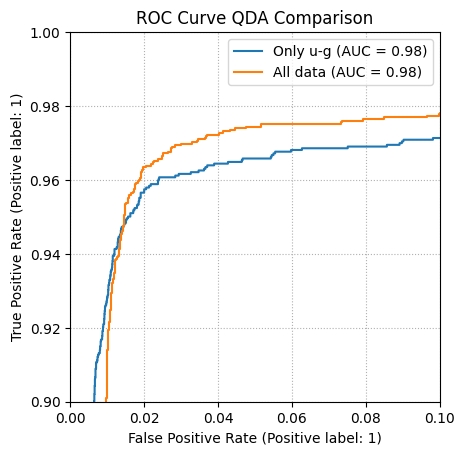

In [256]:
fig, ax = plt.subplots()

RocCurveDisplay.from_predictions(y_test, y_proba, name="Only u-g", ax=ax)
RocCurveDisplay.from_predictions(y_test_AD, y_proba2, name="All data", ax=ax)

ax.set_title("ROC Curve QDA Comparison")
plt.grid(linestyle = ':')
plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.show()

## GaussianNB Classifier

In [257]:
NB = GaussianNB()
NB.fit(ug_train[:, None], y_train)

y_pred_NB_ug = NB.predict(ug_test[:, None])
y_proba = NB.predict_proba(ug_test[:, None])[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred_NB_ug)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_NB_ug).ravel()
completeness_tree = tp / (tp + fn)
contamination_tree = fp / (tp + fp)

print("NB accuracy:", accuracy_score(y_test, y_pred_NB_ug))
print(f"Completeness: {completeness_tree:.4f}")
print(f"Contamination: {contamination_tree:.4f}")

ROC AUC: 0.9830464687751467
NB accuracy: 0.9811333333333333
Completeness: 0.9362
Contamination: 0.0668


In [258]:
# All Data

NB = GaussianNB()
NB = GaussianNB().fit(X_train, y_train_AD)

y_pred_NB_AD = NB.predict(X_test)
y_proba2 = NB.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test_AD, y_proba2))

cm = confusion_matrix(y_test_AD, y_pred_NB_AD)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()
#plt.show()

tn, fp, fn, tp = confusion_matrix(y_test_AD, y_pred_NB_AD).ravel()
completeness = tp / (tp + fn)
contamination = fp / (tp + fp)

print("NB accuracy:", accuracy_score(y_test_AD, y_pred_NB_AD))
print(f"Completeness: {completeness:.4f}")
print(f"Contamination: {contamination:.4f}")

ROC AUC: 0.9789586249708437
NB accuracy: 0.9733939393939394
Completeness: 0.9299
Contamination: 0.1094


## Final Test

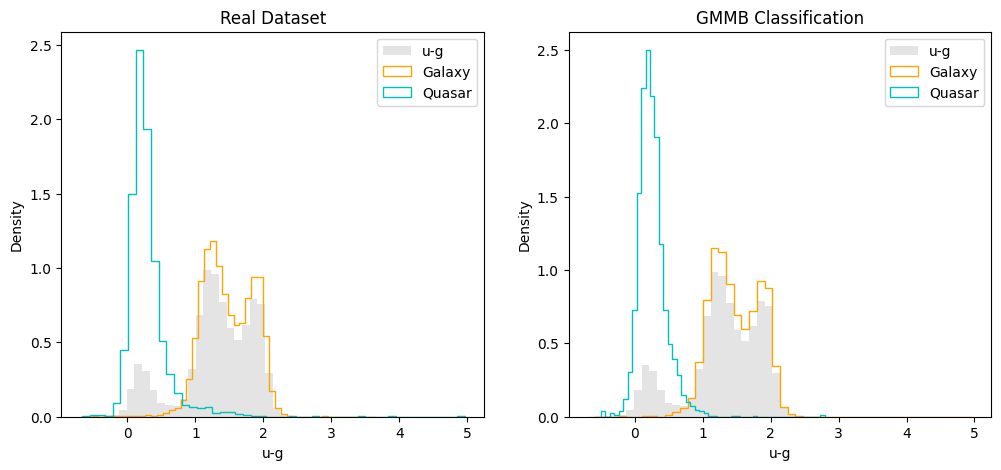

In [261]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

axes[0].hist(X_test[:, 0], bins=50, color='lightgray', label='u-g', alpha=0.6, density=True)
axes[0].hist(X_test[:, 0][y_test_AD == 0], bins=50, color='orange', histtype='step', label='Galaxy', density=True)
axes[0].hist(X_test[:, 0][y_test_AD == 1], bins=50, color='c', histtype='step', label='Quasar', density=True)

axes[0].set_title('Real Dataset')
axes[0].set_xlabel('u-g')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(X_test[:, 0], bins=50, color='lightgray', label='u-g', alpha=0.6, density=True)
axes[1].hist(X_test[:, 0][y_pred_GMMB_AD == 0], bins=50, color='orange', histtype='step', label='Galaxy', density=True)
axes[1].hist(X_test[:, 0][y_pred_GMMB_AD == 1], bins=50, color='c', histtype='step', label='Quasar', density=True)

axes[1].set_title('GMMB Classification')
axes[1].set_xlabel('u-g')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.show()